In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def find_project_root(start_dir: Path) -> Path:
    required = Path("data") / "processed" / "train_data.csv"
    current = start_dir.resolve()

    for _ in range(10):
        if (current / required).exists():
            return current
        if current.parent == current:
            break
        current = current.parent

    raise FileNotFoundError(
        "Could not locate project root containing data/processed/train_data.csv. "
        "Please run this notebook from within the project directory."
    )

project_root = find_project_root(Path.cwd())

train_path = project_root / "data" / "processed" / "train_data.csv"
val_path = project_root / "data" / "processed" / "val_data.csv"
test_path = project_root / "data" / "processed" / "test_data.csv"

model_dir = project_root / "s1_baseline_models" / "baseline_tfidf"
result_dir = project_root / "s1_baseline_results" / "baseline_tfidf"

model_dir.mkdir(parents=True, exist_ok=True)
result_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Train path:", train_path)
print("Val path:", val_path)
print("Test path:", test_path)
print("Model dir:", model_dir)
print("Result dir:", result_dir)

Project root: D:\CSE4601_Text Mining\Yelp_Project
Train path: D:\CSE4601_Text Mining\Yelp_Project\data\processed\train_data.csv
Val path: D:\CSE4601_Text Mining\Yelp_Project\data\processed\val_data.csv
Test path: D:\CSE4601_Text Mining\Yelp_Project\data\processed\test_data.csv
Model dir: D:\CSE4601_Text Mining\Yelp_Project\s1_baseline_models\baseline_tfidf
Result dir: D:\CSE4601_Text Mining\Yelp_Project\s1_baseline_results\baseline_tfidf


In [3]:
print("Loading training, validation, and test datasets ...")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print(f"Train rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Test rows:  {len(test_df)}")
print("Columns:", list(train_df.columns))

Loading training, validation, and test datasets ...
Train rows: 39750
Val rows:   5025
Test rows:  5221
Columns: ['review_id', 'business_id', 'stars', 'text', 'token_count']


In [4]:
X_train = train_df["text"].fillna("").astype(str)
y_train = train_df["stars"].astype(int)

X_val = val_df["text"].fillna("").astype(str)
y_val = val_df["stars"].astype(int)

X_test = test_df["text"].fillna("").astype(str)
y_test = test_df["stars"].astype(int)

print("Data preparation completed.")
print("Example train text length:", len(X_train.iloc[0]) if len(X_train) > 0 else 0)

Data preparation completed.
Example train text length: 513


In [5]:
print("Extracting TF-IDF features ...")

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    min_df=5,
    stop_words="english",
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (val):   {X_val_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")

Extracting TF-IDF features ...
TF-IDF matrix shape (train): (39750, 50000)
TF-IDF matrix shape (val):   (5025, 50000)
TF-IDF matrix shape (test):  (5221, 50000)


In [6]:
print("Training Logistic Regression classifier ...")

clf = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1,
)

clf.fit(X_train_tfidf, y_train)

joblib.dump(tfidf, model_dir / "tfidf_vectorizer.joblib")
joblib.dump(clf, model_dir / "logreg_classifier.joblib")

print("Training completed.")
print("Classes:", clf.classes_)
print("Saved vectorizer and classifier.")

Training Logistic Regression classifier ...


c:\Users\19012\anaconda3\envs\yelp_nlp\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training completed.
Classes: [1 2 3 4 5]
Saved vectorizer and classifier.


In [7]:
def save_confusion_matrix_plot(cm, labels, title, save_path):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def evaluate_and_save(split_name, y_true, y_pred, output_dir):
    labels = ["1 Star", "2 Stars", "3 Stars", "4 Stars", "5 Stars"]
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    report_text = classification_report(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    metrics = {
        "split": split_name,
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "num_samples": int(len(y_true)),
    }

    with open(output_dir / f"{split_name}_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    pd.DataFrame([metrics]).to_csv(output_dir / f"{split_name}_metrics.csv", index=False)
    pd.DataFrame(report_dict).transpose().to_csv(output_dir / f"{split_name}_classification_report.csv")
    pd.DataFrame(cm, index=labels, columns=labels).to_csv(output_dir / f"{split_name}_confusion_matrix.csv")
    pd.DataFrame({"y_true": np.asarray(y_true), "y_pred": np.asarray(y_pred)}).to_csv(
        output_dir / f"{split_name}_predictions.csv", index=False
    )

    with open(output_dir / f"{split_name}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report_text)

    save_confusion_matrix_plot(
        cm,
        labels,
        title=f"Confusion Matrix: TF-IDF + Logistic Regression ({split_name})",
        save_path=output_dir / f"{split_name}_confusion_matrix.png",
    )

    print(f"--- {split_name.upper()} Performance ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print("\n--- Classification Report ---")
    print(report_text)
    print("--- Confusion Matrix (raw) ---")
    print(cm)

    return metrics

Evaluating on validation set ...


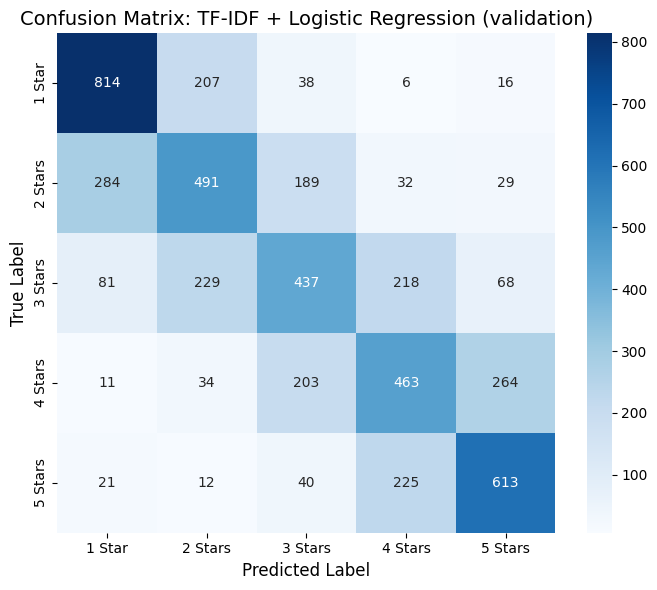

--- VALIDATION Performance ---
Accuracy: 0.5608
Macro-F1: 0.5560

--- Classification Report ---
              precision    recall  f1-score   support

           1       0.67      0.75      0.71      1081
           2       0.50      0.48      0.49      1025
           3       0.48      0.42      0.45      1033
           4       0.49      0.47      0.48       975
           5       0.62      0.67      0.64       911

    accuracy                           0.56      5025
   macro avg       0.55      0.56      0.56      5025
weighted avg       0.55      0.56      0.56      5025

--- Confusion Matrix (raw) ---
[[814 207  38   6  16]
 [284 491 189  32  29]
 [ 81 229 437 218  68]
 [ 11  34 203 463 264]
 [ 21  12  40 225 613]]

Evaluating on test set ...


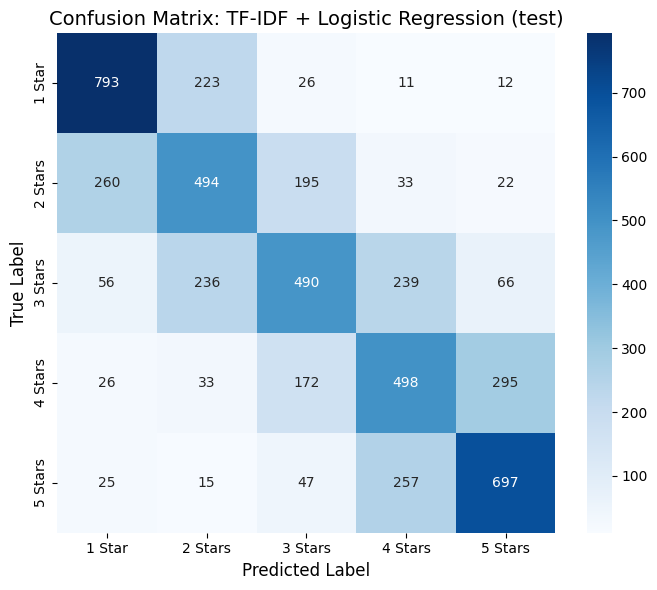

--- TEST Performance ---
Accuracy: 0.5692
Macro-F1: 0.5656

--- Classification Report ---
              precision    recall  f1-score   support

           1       0.68      0.74      0.71      1065
           2       0.49      0.49      0.49      1004
           3       0.53      0.45      0.49      1087
           4       0.48      0.49      0.48      1024
           5       0.64      0.67      0.65      1041

    accuracy                           0.57      5221
   macro avg       0.56      0.57      0.57      5221
weighted avg       0.57      0.57      0.57      5221

--- Confusion Matrix (raw) ---
[[793 223  26  11  12]
 [260 494 195  33  22]
 [ 56 236 490 239  66]
 [ 26  33 172 498 295]
 [ 25  15  47 257 697]]


,split,accuracy,macro_f1,num_samples
0,validation,0.560796,0.555954,5025
1,test,0.569240,0.565603,5221


In [8]:
print("Evaluating on validation set ...")
val_pred = clf.predict(X_val_tfidf)
val_metrics = evaluate_and_save("validation", y_val, val_pred, result_dir)

print("\nEvaluating on test set ...")
test_pred = clf.predict(X_test_tfidf)
test_metrics = evaluate_and_save("test", y_test, test_pred, result_dir)

summary_df = pd.DataFrame([val_metrics, test_metrics])
summary_df.to_csv(result_dir / "metrics_summary.csv", index=False)
display(summary_df)

In [9]:
print("\n--- Feature Importance (Top 10 n-grams per class) ---")

feature_names = np.array(tfidf.get_feature_names_out())
classes = clf.classes_
top_feature_rows = []

for i, class_label in enumerate(classes):
    top_indices = np.argsort(clf.coef_[i])[-10:]
    top_features = feature_names[top_indices]
    top_weights = clf.coef_[i][top_indices]

    top_features_desc = list(reversed(top_features.tolist()))
    top_weights_desc = list(reversed(top_weights.tolist()))
    print(f"Star Rating {class_label}: {', '.join(top_features_desc)}")

    for feature, weight in zip(top_features_desc, top_weights_desc):
        top_feature_rows.append(
            {"class_label": int(class_label), "feature": feature, "weight": float(weight)}
        )

pd.DataFrame(top_feature_rows).to_csv(result_dir / "top_features_by_class.csv", index=False)


--- Feature Importance (Top 10 n-grams per class) ---
Star Rating 1: worst, horrible, terrible, rude, awful, money, zero, told, disgusting, dirty
Star Rating 2: mediocre, bland, meh, ok, unfortunately, won, disappointing, disappointed, okay, dry
Star Rating 3: ok, decent, good, okay, stars, average, bit, pretty, little, alright
Star Rating 4: great, delicious, excellent, good, enjoyed, definitely, little, bit, awesome, friendly
Star Rating 5: amazing, best, delicious, great, awesome, love, excellent, perfect, favorite, fantastic



Generating top n-gram importance plots ...


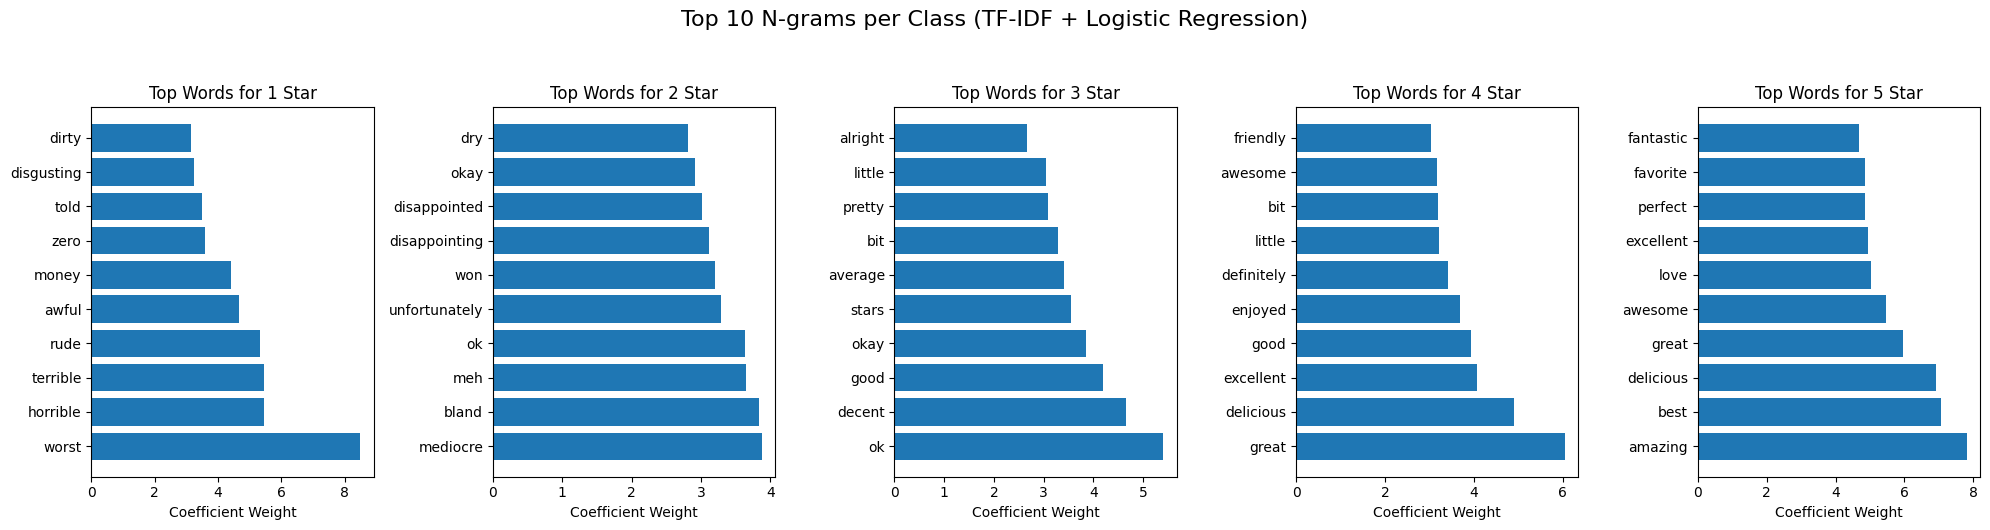

Top n-gram importance plots generated and saved.


In [10]:
print("\nGenerating top n-gram importance plots ...")

feature_names = np.array(tfidf.get_feature_names_out())
classes = clf.classes_

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharex=False)

for i, class_label in enumerate(classes):
    top_indices = np.argsort(clf.coef_[i])[-10:]
    top_features = feature_names[top_indices]
    top_weights = clf.coef_[i][top_indices]

    axes[i].barh(top_features, top_weights)
    axes[i].set_title(f"Top Words for {int(float(class_label))} Star", fontsize=12)
    axes[i].set_xlabel("Coefficient Weight")
    axes[i].invert_yaxis()

plt.suptitle("Top 10 N-grams per Class (TF-IDF + Logistic Regression)", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig(result_dir / "top_ngrams_tfidf.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Top n-gram importance plots generated and saved.")